# A notebook to evaluate fingerprint trained model and comparison between transfer learning vs. fine tuning 

## Project Pre-requisites

In [1]:
# Import libraries
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, saving

from tensorflow.keras.utils import image_dataset_from_directory

# pre-trained model selection
MobileNet_version = "MobileNetV2"
fingerprint_model_name = MobileNet_version + "_FingerPrint_Model"
fingerprint_basemodel_name = MobileNet_version + "_FingerPrint_BaseModel"

if MobileNet_version == "MobileNet":
    from tensorflow.keras.applications import MobileNet
    from tensorflow.keras.applications.mobilenet import preprocess_input
elif MobileNet_version == "MobileNetV2":
    from tensorflow.keras.applications import MobileNetV2
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
elif MobileNet_version == "MobileNetV3Small":
    from tensorflow.keras.applications import MobileNetV3Small
    from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
elif MobileNet_version == "MobileNetV3Large":
    from tensorflow.keras.applications import MobileNetV3Large
    from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
else:
    print("Unknown MobileNet version name")
    exit(0)

In [2]:
# Check selected pre-trained model
print(f"Selected pre-trained model version : {MobileNet_version}")
print(f"Fingerprint model name : {fingerprint_model_name}")

Selected pre-trained model version : MobileNetV2
Fingerprint model name : MobileNetV2_FingerPrint_Model


In [3]:
# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU (entraînement sera lent)")
except Exception as e:
    print(f"Configuration GPU: {e}")

print(f"\n📦 Versions des bibliothèques :")
print(f"  - TensorFlow : {tf.__version__}")
print(f"  - Keras      : {keras.__version__}")
print(f"  - NumPy      : {np.__version__}")

print(f"\n🚀 Prêt pour le transfer learning en computer vision !")

✅ GPU(s) détecté(s): 1 - Croissance mémoire activée

📦 Versions des bibliothèques :
  - TensorFlow : 2.16.2
  - Keras      : 3.13.2
  - NumPy      : 1.26.4

🚀 Prêt pour le transfer learning en computer vision !


## Project Constants

In [4]:
# Random seeding 
TENSORFLOW_SEED = 42
tf.random.set_seed(TENSORFLOW_SEED)

NUMPY_SEED = 42
np.random.seed(NUMPY_SEED)

# Dataset configuration

DATASET_ROOTDIR_PATH = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Custom" 
print(f"📁 Fingerprints dataset images root directory path : {DATASET_ROOTDIR_PATH}")

# labels
# class_names = ['thumb', 'index', 'middle', 'ring', 'little']
class_names = ['thumb', 'index', 'middle', 'ring']

num_classes = len(class_names)
print(f"\n👁️ fingerprints classes : {class_names}")

# model name
fingerprint_model_basename = fingerprint_model_name + "_" + str(num_classes) + "_classes"
print(f"Adjusted fingerprint model name : {fingerprint_model_basename}")

📁 Fingerprints dataset images root directory path : /Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Custom

👁️ fingerprints classes : ['thumb', 'index', 'middle', 'ring']
Adjusted fingerprint model name : MobileNetV2_FingerPrint_Model_4_classes


In [5]:
print("🔧 Datasets creation for training and validation/test ...\n")

# Dataset creation parameters
BATCH_SIZE = 64
IMAGE_SIZE = (96, 96)

# Create traning dataset with class filtering
dataset_train_dir = DATASET_ROOTDIR_PATH + "/train"
train_ds = image_dataset_from_directory(
    dataset_train_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # One-hot encoding for multi-class
    class_names=class_names  # Explicitly specify the class names to ensure correct mapping
)

# Create validation dataset with the same class names to ensure correct mapping
dataset_val_dir = DATASET_ROOTDIR_PATH + "/validation"
val_test_ds = image_dataset_from_directory(
    dataset_val_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=class_names  # Same order of classes
)

# split validation dataset into 2 using 2/3 validation and 1/3 test ratio
val_batches = tf.data.experimental.cardinality(val_test_ds)
test_ds_cardinality = int(val_batches * 33 / 100)

test_ds = val_test_ds.take(test_ds_cardinality)
test_ds.class_names = class_names
val_ds = val_test_ds.skip(test_ds_cardinality)
val_ds.class_names = class_names

print(f"✅ Datasets created !\n")

print(f"📊 Training, validation and datasets information:")
print(f"  - Training Dataset Classes        : {train_ds.class_names}")
print(f"  - Validation Dataset Classes      : {val_ds.class_names}")
print(f"  - Test Dataset Classes            : {test_ds.class_names}")

# Checking number of classes in both datasets
if len(train_ds.class_names) != num_classes:
    print(f"\n⚠️  Error : {len(train_ds.class_names)} classes found instead of {num_classes} in training dataset !")
    print(f"   Classes found: {train_ds.class_names}\n")
elif len(val_test_ds.class_names) != num_classes:
    print(f"\n⚠️  Error : {len(val_test_ds.class_names)} classes found instead of {num_classes} in validation dataset !")
    print(f"   Classes found : {val_test_ds.class_names}")
else:
    print(f"  - ✅ Number of correct classes : {num_classes} \n")

print(f"  - Training batches    : {len(train_ds)}")
print(f"  - Validation batches  : {len(val_ds)}")
print(f"  - Test batches        : {len(test_ds)}")
print(f"  - Batch size          : {BATCH_SIZE}")
print(f"  - Training samples    : ~{len(train_ds) * BATCH_SIZE}")
print(f"  - Validation samples  : ~{len(val_ds) * BATCH_SIZE}")
print(f"  - Test samples        : ~{len(test_ds) * BATCH_SIZE}")

🔧 Datasets creation for training and validation/test ...

Found 12766 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
✅ Datasets created !

📊 Training, validation and datasets information:
  - Training Dataset Classes        : ['thumb', 'index', 'middle', 'ring']
  - Validation Dataset Classes      : ['thumb', 'index', 'middle', 'ring']
  - Test Dataset Classes            : ['thumb', 'index', 'middle', 'ring']
  - ✅ Number of correct classes : 4 

  - Training batches    : 200
  - Validation batches  : 17
  - Test batches        : 8
  - Batch size          : 64
  - Training samples    : ~12800
  - Validation samples  : ~1088
  - Test samples        : ~512


2026-03-26 11:00:23.154388: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-03-26 11:00:23.154421: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-26 11:00:23.154429: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-26 11:00:23.154447: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-26 11:00:23.154458: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Dataset Preparation : normalization and shuffling (training only), no augmentation

In [6]:
print("🎨 Fingerprint dataset preparation : normalisation and shuffling (training only) ...\n")

# Dataset preparation function
def prepare_dataset(ds, shuffle=True):

    # normalisation required for MobileNet
    normalization = lambda x, y: (preprocess_input(x), y)
    ds = ds.map(normalization, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Shuffle (training only)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    
    # Performances optimisation
    ds = ds.cache()  # Memory caching
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)  # Prefetch for acceleration
    
    return ds

# Apply transformations
train_ds_prepared = prepare_dataset(train_ds, shuffle=True)
val_ds_prepared = prepare_dataset(val_ds, shuffle=False)
test_ds_prepared = prepare_dataset(test_ds, shuffle=False)

print("✅ Dataset preparation completed !\n")

print("📝 Applied transformations :")
print("  - Training dataset             : normalisation + shuffle")
print("  - Validation and test dataset  : normalisation only")
print("\n  - Caching et prefetch activated for performance")

🎨 Fingerprint dataset preparation : normalisation and shuffling (training only) ...

✅ Dataset preparation completed !

📝 Applied transformations :
  - Training dataset             : normalisation + shuffle
  - Validation and test dataset  : normalisation only

  - Caching et prefetch activated for performance


## Loading  Previously Trained model after transfer learning with pre-trained based model

In [7]:
fingerprint_model_dir = "/Users/laurent/Projects/projet-fingerprint-validator/models"

def load_fingerprint_model(name: str, path: str, stage: str):

    print(f"📥 Loading Previously Trained {name} model after {stage} ...")

    # Loading fingerprint model 
    try:
        fingerprint_model = tf.keras.models.load_model(path, compile=True)
    except Exception as e:
        print(f"Unable to load model after {stage} : {path} : {e}")
        return None

    print(f"✅ {name} model loaded !\n")

    # Display model structure
    print(f"📋 Model Structure - {name} :")
    print(f"  - Input shape    : {fingerprint_model.input_shape}")
    print(f"  - Output shape   : {fingerprint_model.output_shape}")
    print(f"  - Number of layers : {len(fingerprint_model.layers)}")

    # Count parameters
    total_params = fingerprint_model.count_params()
    print(f"\n  - Total number of parameters : {total_params:,}")
    print(f"  - Memory size (approx.) : {total_params * 4 / (1024**2):.1f} MB")

    return fingerprint_model

In [8]:
fingerprint_transfer_learning_model_name = fingerprint_model_basename + "_Transfer_Learning.keras"
fingerprint_transfer_learning_model_path = fingerprint_model_dir + "/" + fingerprint_transfer_learning_model_name

fingerprint_transfer_learning_model = load_fingerprint_model(fingerprint_transfer_learning_model_name, 
                                                             fingerprint_transfer_learning_model_path, 
                                                             "transfer learning")

📥 Loading Previously Trained MobileNetV2_FingerPrint_Model_4_classes_Transfer_Learning.keras model after transfer learning ...
✅ MobileNetV2_FingerPrint_Model_4_classes_Transfer_Learning.keras model loaded !

📋 Model Structure - MobileNetV2_FingerPrint_Model_4_classes_Transfer_Learning.keras :
  - Input shape    : (None, 96, 96, 3)
  - Output shape   : (None, 4)
  - Number of layers : 8

  - Total number of parameters : 2,602,628
  - Memory size (approx.) : 9.9 MB


In [9]:
fingerprint_transfer_learning_model.summary()

Model: "MobileNetV2_FingerPrint_Model_4_classes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV2_FingerPrint_BaseMo… │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,291,918 (12.56 MB)

 Trainable params: 344,644 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 689,290 (2.63 MB)

## Loading  Previously Trained model after fine-tuning with pre-trained based model

In [10]:
fingerprint_fine_tuning_model_name = fingerprint_model_basename + "_Fine_Tuning.keras"
fingerprint_fine_tuning_model_path = fingerprint_model_dir + "/" + fingerprint_fine_tuning_model_name

fingerprint_fine_tuning_model = load_fingerprint_model(fingerprint_fine_tuning_model_name, 
                                                       fingerprint_fine_tuning_model_path, 
                                                       "fine tuning")

📥 Loading Previously Trained MobileNetV2_FingerPrint_Model_4_classes_Fine_Tuning.keras model after fine tuning ...
✅ MobileNetV2_FingerPrint_Model_4_classes_Fine_Tuning.keras model loaded !

📋 Model Structure - MobileNetV2_FingerPrint_Model_4_classes_Fine_Tuning.keras :
  - Input shape    : (None, 96, 96, 3)
  - Output shape   : (None, 4)
  - Number of layers : 8

  - Total number of parameters : 2,602,628
  - Memory size (approx.) : 9.9 MB


In [11]:
fingerprint_fine_tuning_model.summary()

Model: "MobileNetV2_FingerPrint_Model_4_classes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV2_FingerPrint_BaseMo… │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,002,126 (26.71 MB)

 Trainable params: 2,199,748 (8.39 MB)

 Non-trainable params: 402,880 (1.54 MB)

 Optimizer params: 4,399,498 (16.78 MB)

## Compare transfer learning and fine tuning models performances

In [12]:
# Evaluate transfer learning model with test dataset
print("📊 Evaluate transfer learning model with test dataset...\n")

results_val_frozen = fingerprint_transfer_learning_model.evaluate(val_ds_prepared, verbose=0)
val_accuracy_frozen = results_val_frozen[1]

results_frozen = fingerprint_transfer_learning_model.evaluate(test_ds_prepared, verbose=0)
test_accuracy_frozen = results_frozen[1]

print("Results :")
print(f"  - Loss                : {results_frozen[0]:.4f}")
print(f"  - Accuracy            : {test_accuracy_frozen*100:.2f}%")
print(f"  - Top-2 Accuracy      : {results_frozen[2]*100:.2f}%")

print(f"\nCheck overfitting :")
print(f"  - Validation Accuracy : {val_accuracy_frozen*100:.2f}")
print(f"  - Test Accuracy       : {test_accuracy_frozen*100:.2f}")

📊 Evaluate transfer learning model with test dataset...



2026-03-26 11:00:25.787265: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Results :
  - Loss                : 0.8302
  - Accuracy            : 68.36%
  - Top-2 Accuracy      : 89.65%

Check overfitting :
  - Validation Accuracy : 66.27
  - Test Accuracy       : 68.36


In [13]:
# Evaluate fine tuned model with test dataset
print("📊 Evaluate fine tuned model with test dataset...\n")

results_val_finetuned = fingerprint_fine_tuning_model.evaluate(val_ds_prepared, verbose=0)
val_accuracy_finetuned = results_val_finetuned[1]

results_finetuned = fingerprint_fine_tuning_model.evaluate(test_ds_prepared, verbose=0)
test_accuracy_finetuned = results_finetuned[1]

print("Results :")
print(f"  - Loss                : {results_finetuned[0]:.4f}")
print(f"  - Accuracy            : {test_accuracy_finetuned*100:.2f}%")
print(f"  - Top-2 Accuracy      : {results_finetuned[2]*100:.2f}%")

print(f"\nCheck overfitting :")
print(f"  - Validation Accuracy : {val_accuracy_finetuned*100:.2f}")
print(f"  - Test Accuracy       : {test_accuracy_finetuned*100:.2f}")

📊 Evaluate fine tuned model with test dataset...

Results :
  - Loss                : 1.1350
  - Accuracy            : 69.73%
  - Top-2 Accuracy      : 91.80%

Check overfitting :
  - Validation Accuracy : 69.85
  - Test Accuracy       : 69.73


In [14]:
print("📊 Comparison : Transfer Learning vs Fine-Tuning\n")
print("="*80)

# Create dataframe
comparison_data = {
    'Metric': ['Val Loss', 'Val Accuracy', 'Val Top-2 Accuracy'],
    'Transfer Learning (Frozen)': [
        f"{results_frozen[0]:.4f}",
        f"{results_frozen[1]*100:.2f}%",
        f"{results_frozen[2]*100:.2f}%"
    ],
    'Fine-Tuning (Unfrozen)': [
        f"{results_finetuned[0]:.4f}",
        f"{results_finetuned[1]*100:.2f}%",
        f"{results_finetuned[2]*100:.2f}%"
    ],
    'Improvement': [
        f"{(results_frozen[0] - results_finetuned[0]):.4f}",
        f"{(results_finetuned[1] - results_frozen[1])*100:.2f}%",
        f"{(results_finetuned[2] - results_frozen[2])*100:.2f}%"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))
print("\n" + "="*80)

# More Information
print("\n🔍 Analysis :")
if results_finetuned[1] > results_frozen[1]:
    improvement = (results_finetuned[1] - results_frozen[1]) * 100
    print(f"  ✅ Fine-tuning improves accuracy by {improvement:.2f}% !")
else:
    print("  ⚠️  Transfer Learning (feature extraction) perform as much or better.")


📊 Comparison : Transfer Learning vs Fine-Tuning

            Metric Transfer Learning (Frozen) Fine-Tuning (Unfrozen) Improvement
          Val Loss                     0.8302                 1.1350     -0.3048
      Val Accuracy                     68.36%                 69.73%       1.37%
Val Top-2 Accuracy                     89.65%                 91.80%       2.15%


🔍 Analysis :
  ✅ Fine-tuning improves accuracy by 1.37% !


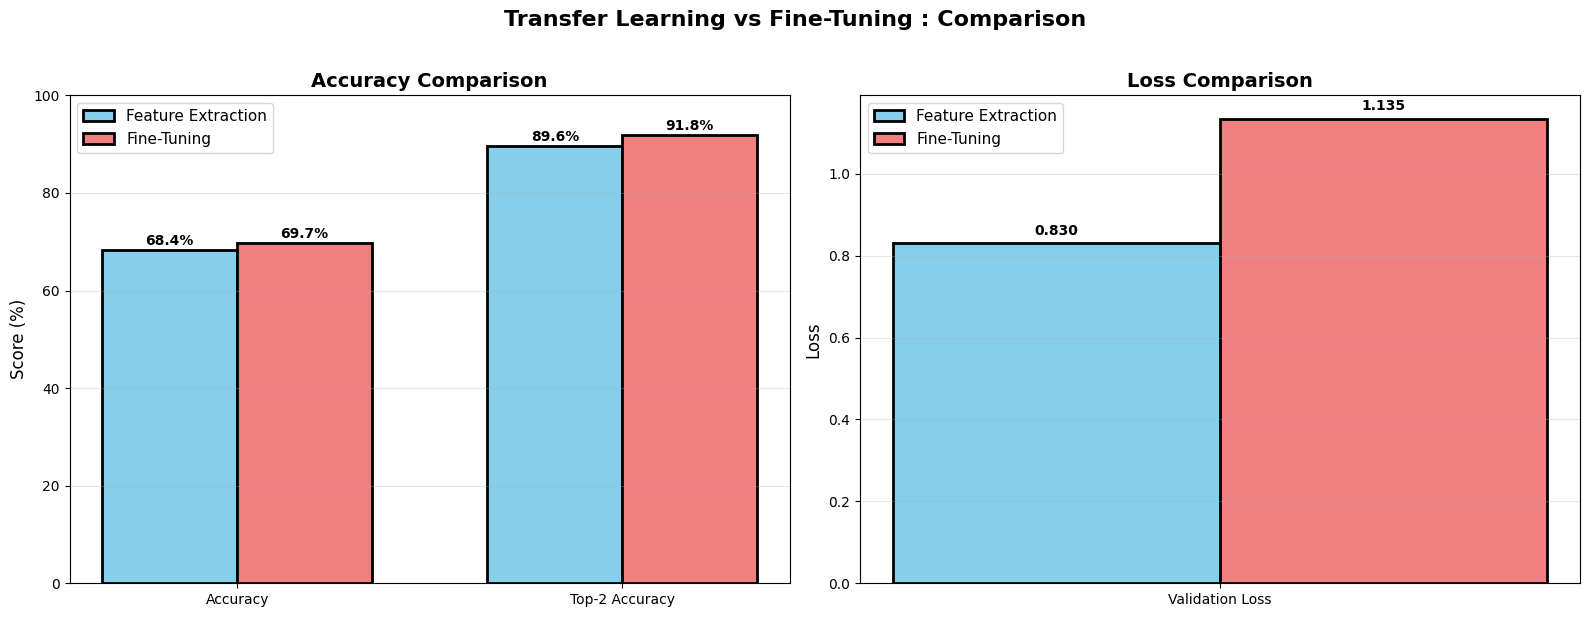

In [15]:
# Graph for comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracies comparison
metrics = ['Accuracy', 'Top-2 Accuracy']
frozen_scores = [results_frozen[1]*100, results_frozen[2]*100]
finetuned_scores = [results_finetuned[1]*100, results_finetuned[2]*100]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, frozen_scores, width, label='Feature Extraction', color='skyblue', edgecolor='black', linewidth=2)
axes[0].bar(x + width/2, finetuned_scores, width, label='Fine-Tuning', color='lightcoral', edgecolor='black', linewidth=2)
axes[0].set_ylabel('Score (%)', fontsize=12)
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3, axis='y')
axes[0].set_ylim([0, 100])

# Ajouter les valeurs sur les barres
for i, (f, ft) in enumerate(zip(frozen_scores, finetuned_scores)):
    axes[0].text(i - width/2, f + 1, f'{f:.1f}%', ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i + width/2, ft + 1, f'{ft:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Comparaison des loss
categories = ['Validation Loss']
frozen_loss = [results_frozen[0]]
finetuned_loss = [results_finetuned[0]]

x2 = np.arange(len(categories))
axes[1].bar(x2 - width/2, frozen_loss, width, label='Feature Extraction', color='skyblue', edgecolor='black', linewidth=2)
axes[1].bar(x2 + width/2, finetuned_loss, width, label='Fine-Tuning', color='lightcoral', edgecolor='black', linewidth=2)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(categories)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, axis='y')

# Ajouter les valeurs
axes[1].text(x2[0] - width/2, frozen_loss[0] + 0.02, f'{frozen_loss[0]:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].text(x2[0] + width/2, finetuned_loss[0] + 0.02, f'{finetuned_loss[0]:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Transfer Learning vs Fine-Tuning : Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Confusion Matrix

📊 Confusion Matrix and Detailed Analysis...



2026-03-26 11:00:34.801225: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


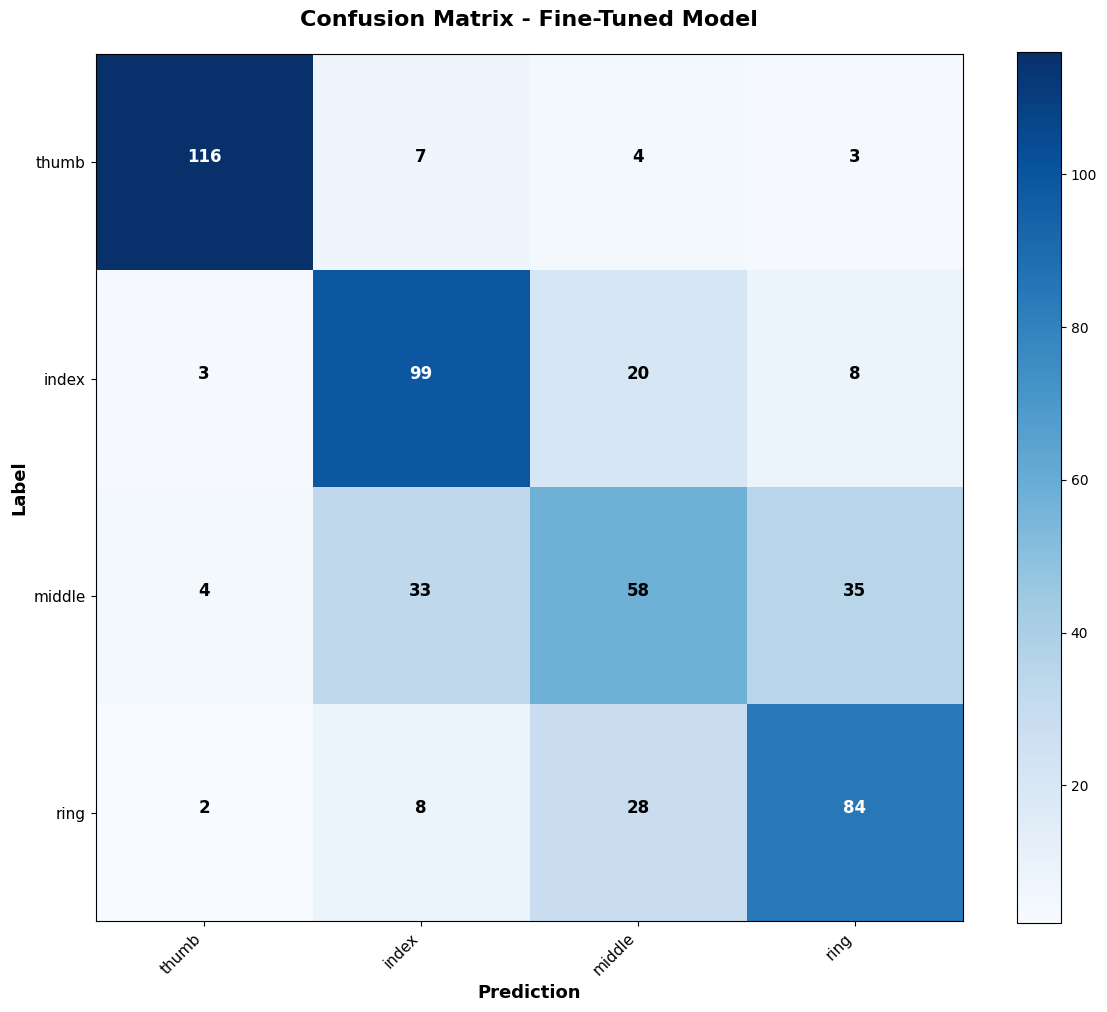


📄 Detailed classification report :

              precision    recall  f1-score   support

       thumb      0.928     0.892     0.910       130
       index      0.673     0.762     0.715       130
      middle      0.527     0.446     0.483       130
        ring      0.646     0.689     0.667       122

    accuracy                          0.697       512
   macro avg      0.694     0.697     0.694       512
weighted avg      0.694     0.697     0.694       512



In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools

print("📊 Confusion Matrix and Detailed Analysis...\n")

# Get the predictions
y_true = []
y_pred = []

for images, labels in test_ds_prepared:
    predictions = fingerprint_fine_tuning_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Fine-Tuned Model', fontsize=16, fontweight='bold', pad=20)
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right', fontsize=11)
plt.yticks(tick_marks, class_names, fontsize=11)

# Add values in cells
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black",
             fontsize=12, fontweight='bold')

plt.ylabel('Label', fontsize=13, fontweight='bold')
plt.xlabel('Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Dump classification report
print("\n📄 Detailed classification report :\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

## Detailed Analysis by Class

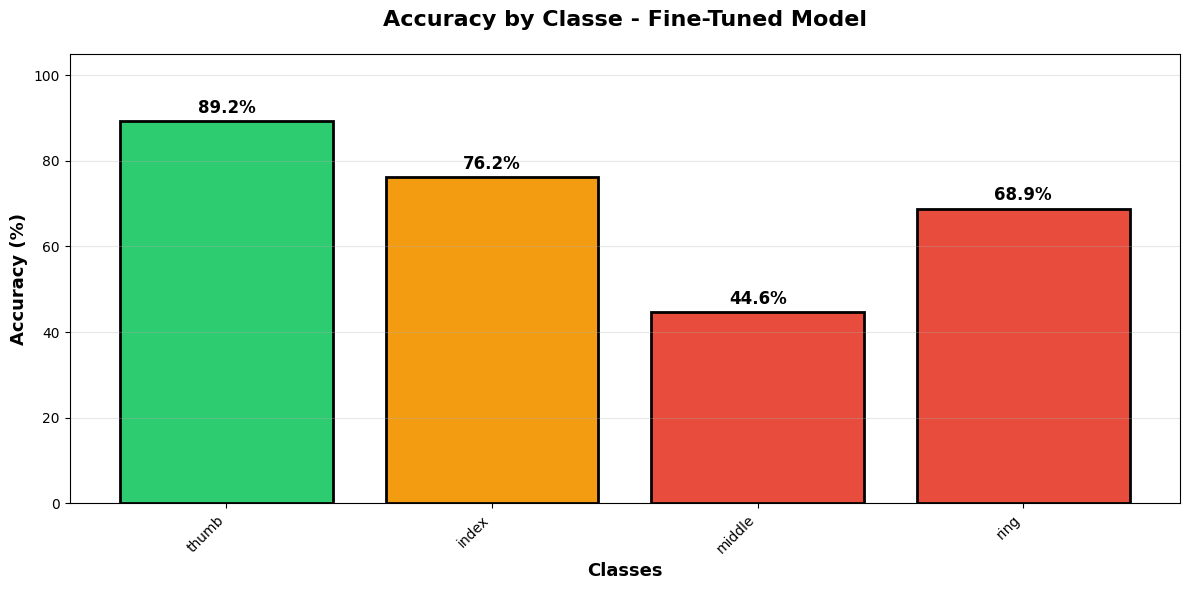


🏆 Best class : thumb (89.2%)
⚠️  Worst class : middle (44.6%)


In [17]:
# Compute accuracy by class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ecc71' if acc > 0.85 else '#f39c12' if acc > 0.75 else '#e74c3c' for acc in class_accuracies]
bars = ax.bar(class_names, class_accuracies * 100, color=colors, edgecolor='black', linewidth=2)

# Add bar values
for bar, acc in zip(bars, class_accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{acc*100:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Classes', fontsize=13, fontweight='bold')
ax.set_title('Accuracy by Classe - Fine-Tuned Model', fontsize=16, fontweight='bold', pad=20)
ax.set_ylim([0, 105])
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Identify best and worst classes
best_class_idx = np.argmax(class_accuracies)
worst_class_idx = np.argmin(class_accuracies)

print(f"\n🏆 Best class : {class_names[best_class_idx]} ({class_accuracies[best_class_idx]*100:.1f}%)")
print(f"⚠️  Worst class : {class_names[worst_class_idx]} ({class_accuracies[worst_class_idx]*100:.1f}%)")

## Prepare Model for production with prediction function

In [18]:
def predict_fingerprint(model, image_input_size, fingerprint_image_path, class_names, topk_predictions):
    """
    Predict the fingerprint class given an image with fine)tuned model
    
    Args:
        model: Fine-Tuned Keras model
        image_input_size: size of images expected for the trained model
        fingerprint_image_path: fingerprint image path
        class_names: classes names
        topk_predictions: integer for reporting top-k predictions
    """

    try:
        # Load and prep image for prediction
        img = tf.keras.preprocessing.image.load_img(fingerprint_image_path, target_size=image_input_size)

        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)  # Add batch dimension
        img_array = preprocess_input(img_array)  # Normalisation with MobileNet
    except Exception as e:
        print(f"")
        return(0)
    
    # Prediction
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx]
    
    # Report top-k prédictions
    topk_idx = np.argsort(predictions[0])[-topk_predictions:][::-1]
    
    return {
        'predicted_class': class_names[predicted_class_idx],
        'confidence': confidence,
        'all_probabilities': predictions[0],        
        'top-k': [(class_names[i], predictions[0][i]) for i in topk_idx]
    }

print("✅ Prediction function created !")

✅ Prediction function created !


🔮 Predictions using randomly selected images...



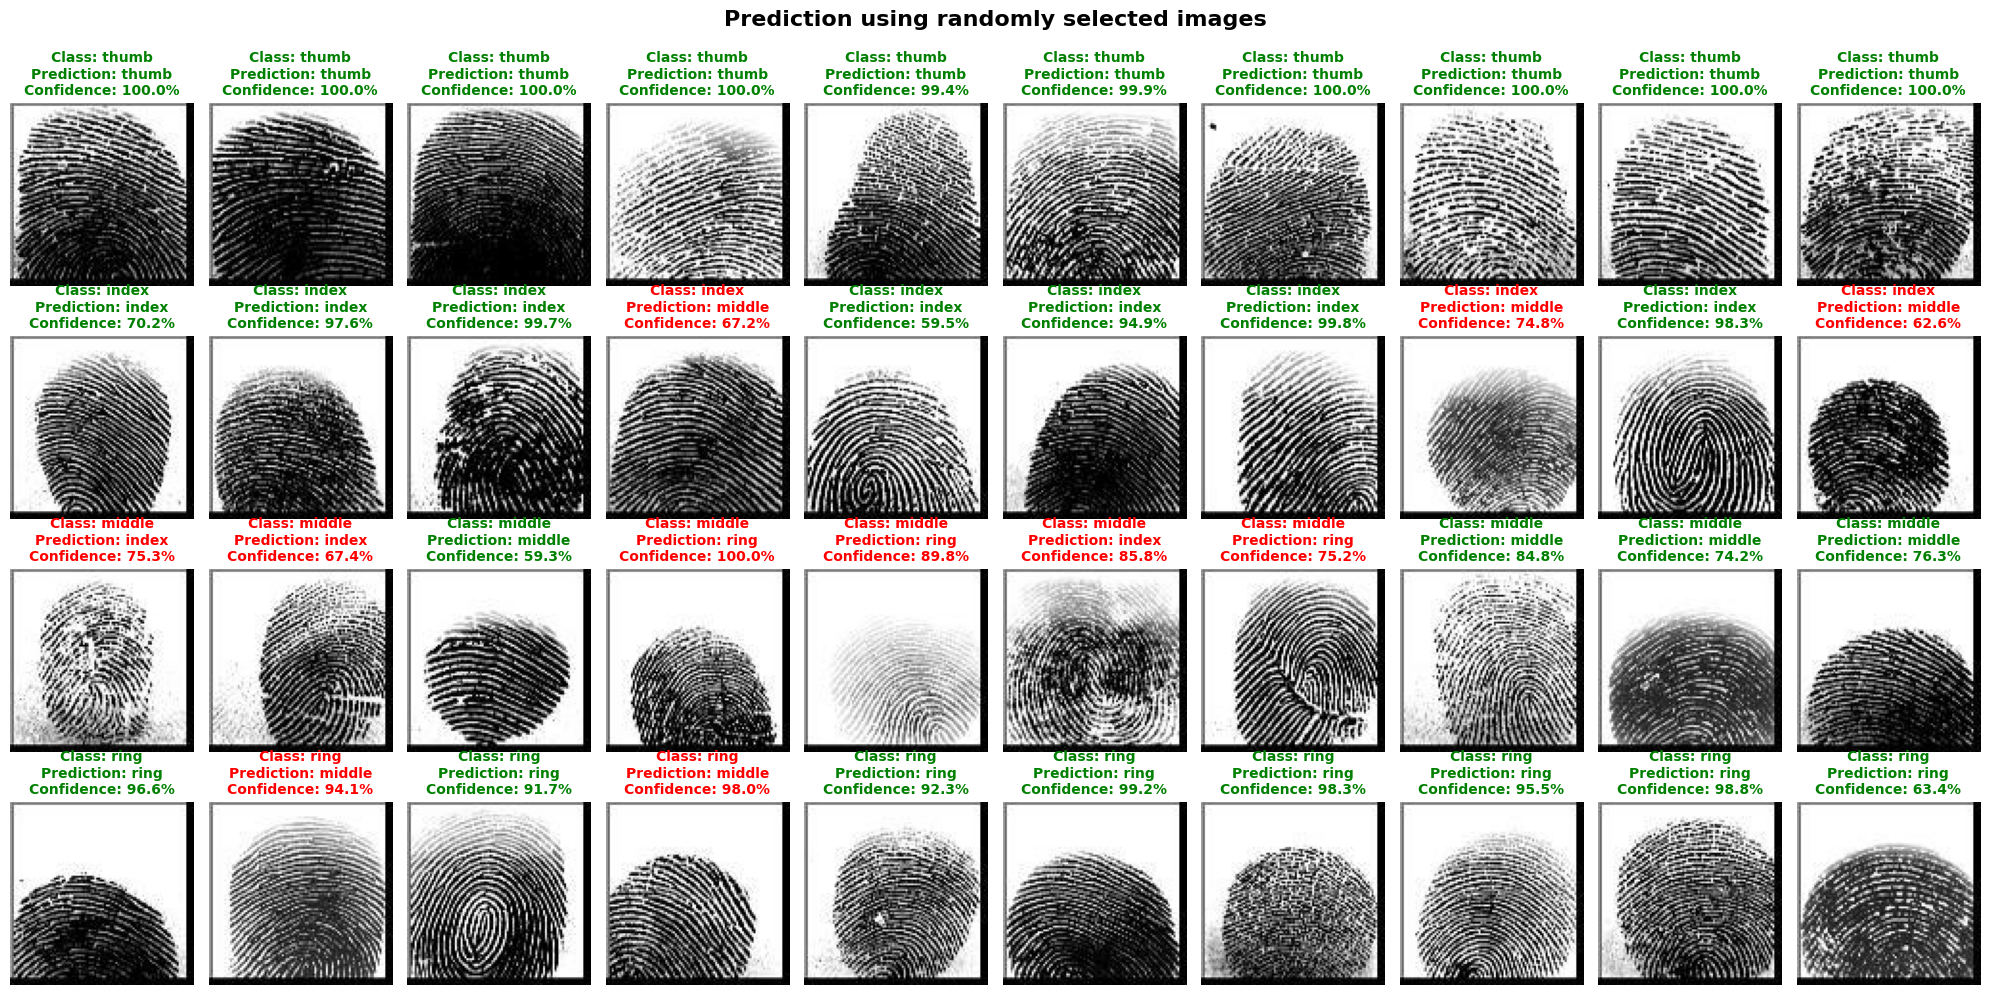

In [19]:
print("🔮 Predictions using randomly selected images...\n")

num_examples_prediction = 10

# Select randomly a few images
test_images_predictions = []

for class_name in class_names:
    class_path = Path(os.path.join(DATASET_ROOTDIR_PATH + "/validation", class_name))
    images = list(class_path.glob('*.*'))

    # Randomly select num_examples images in each class
    test_images_predictions.extend(random.sample(images, min(num_examples_prediction, len(images))))

fig, axes = plt.subplots(len(class_names), num_examples_prediction, figsize=(20, 10))
axes = axes.flatten()

for idx, img_path in enumerate(test_images_predictions[:num_examples_prediction * len(class_names)]):
    # Predict
    result = predict_fingerprint(fingerprint_fine_tuning_model, IMAGE_SIZE, img_path, class_names, 2)
    
    # Display image
    img = plt.imread(img_path)
    axes[idx].imshow(img)
    axes[idx].axis('off')
    
    # Vraie classe (depuis le nom du dossier)
    filename = os.path.basename(img_path)
    if filename.find("thumb") != -1:
        true_class = "thumb"
    elif filename.find("index") != -1:
        true_class = "index"
    elif filename.find("middle") != -1:
        true_class = "middle"
    elif filename.find("ring") != -1:
        true_class = "ring"
    elif filename.find("little") != -1:
        true_class = "little"
    else:
        true_class = None
    
    predicted_class = result['predicted_class']
    confidence = result['confidence']
    
    # Color-code result : green-correct vs. red-incorrect 
    color = 'green' if true_class == predicted_class else 'red'
    
    # Title
    title = f"Class: {true_class}\nPrediction: {predicted_class}\nConfidence: {confidence*100:.1f}%"
    axes[idx].set_title(title, fontsize=10, color=color, fontweight='bold')

plt.suptitle('Prediction using randomly selected images', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

## VIsualize all probabilities for a few selected images

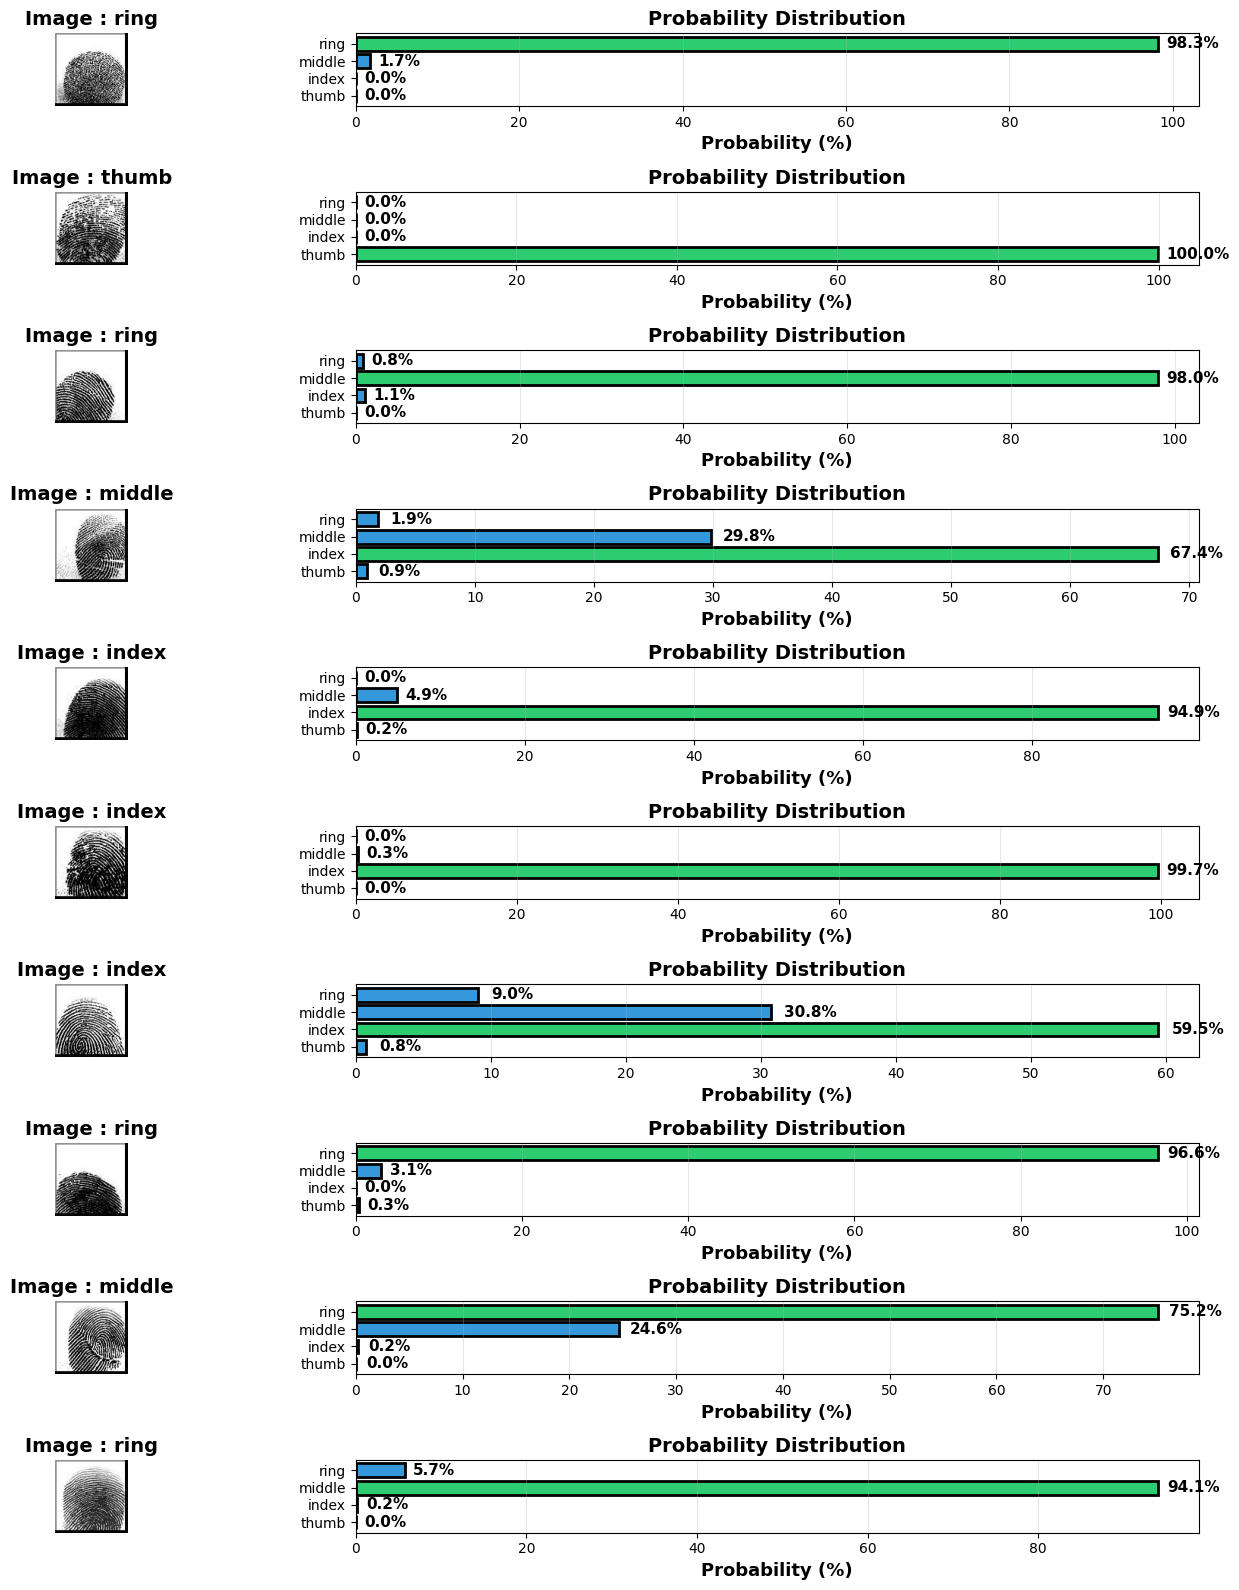

In [20]:
# Select few images from the above set
num_examples_probabilities = 10

# Randomly select num_examples images in each class
test_images_probabilities = random.sample(test_images_predictions, num_examples_probabilities)

fig, axes = plt.subplots(num_examples_probabilities, 2, figsize=(16, 16))

for idx, img_path in enumerate(test_images_probabilities[:num_examples_probabilities]):

    sample_image_path = test_images_probabilities[idx]
    result = predict_fingerprint(fingerprint_fine_tuning_model, IMAGE_SIZE, sample_image_path, class_names, 2)

    # Image
    img = plt.imread(sample_image_path)
    axes[idx, 0].imshow(img)
    axes[idx, 0].axis('off')
    axes[idx, 0].set_title(f"Image : {sample_image_path.parent.name}", fontsize=14, fontweight='bold')

    # Probabilities
    probs = result['all_probabilities'] * 100
    colors = ['#2ecc71' if i == np.argmax(probs) else '#3498db' for i in range(len(probs))]

    bars = axes[idx, 1].barh(class_names, probs, color=colors, edgecolor='black', linewidth=2)
    axes[idx, 1].set_xlabel('Probability (%)', fontsize=13, fontweight='bold')
    axes[idx, 1].set_title('Probability Distribution', fontsize=14, fontweight='bold')
    axes[idx, 1].grid(alpha=0.3, axis='x')

    # Add values
    for bar, prob in zip(bars, probs):
        width = bar.get_width()
        axes[idx, 1].text(width + 1, bar.get_y() + bar.get_height()/2.,
                    f'{prob:.1f}%',
                    ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()